## 10. Taller 2

### A. Jugando con la precision en Python
1. Complete y depure `suma_seno` (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.
2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de $x$ entre $0$ y $4\pi$, incluyendo el número de iteraciones, la suma y el error relativo frente a `math.sin`.
3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de $x$ que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de $x$ ocurre y explique a qué se debe.
4. Repita el experimento de la sección 7 para $x$ grande (por ejemplo, $x=100$) **sin** la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.
5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?

### B. Decaimiento radiactivo con Python (Entregar Reporte)

Durante la semana anterior estudiamos el **decaimiento radiactivo utilizando FORTRAN**. En este ejercicio retomaremos el mismo sistema físico, pero utilizaremos Python para trabajar con un conjunto de valores, analizar los resultados y representarlos gráficamente.

El número de núcleos radiactivos presentes en una muestra evoluciona de acuerdo con

$$
N(t)=N_0e^{-\lambda t},
$$

donde $N_0$ es el número inicial de núcleos y $\lambda$ es la constante de decaimiento. Esta constante se relaciona con la vida media $t_{1/2}$ mediante

$$
\lambda=\frac{\ln(2)}{t_{1/2}}.
$$

Considere una muestra con

$$
N_0=10\,000
$$

núcleos radiactivos y una vida media de

$$
t_{1/2}=5\ \mathrm{años}.
$$

#### Actividades

1. Calcule la constante de decaimiento $\lambda$.

2. Utilice `numpy.linspace()` para crear un arreglo de tiempos entre **0 y 30 años**. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra.

3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy.

   **No utilice un ciclo `for` para realizar este cálculo.**

4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:

   - título;
   - nombre de los ejes;
   - unidades;
   - una cuadrícula que facilite la lectura de los resultados.

5. Identifique sobre la gráfica los tiempos correspondientes a **una, dos y tres vidas medias**. Observe qué fracción de la muestra permanece después de cada una de ellas.

6. Determine aproximadamente el tiempo en el cual permanece:

   - el **50 %** de la muestra inicial;
   - el **25 %** de la muestra inicial;
   - el **10 %** de la muestra inicial.

**Objetivo del ejercicio:** aplicar las herramientas básicas de Python estudiadas esta semana a un problema físico conocido y comenzar a utilizar Python para el **manejo, análisis y visualización de resultados científicos**.

### C. Celda de verificación (PASS/FAIL)

Para agilizar la revisión, la tarea debe cerrar con una celda que compruebe automáticamente 2-3 casos conocidos e imprima PASS/FAIL — no hace falta rastrear la lógica a mano para calificar. Abajo hay una celda de verificación para la Parte A (usa `suma_seno_reducida`, ya definida en la sección 7) y una plantilla para la Parte B: complete `N_decaimiento` con $N(t) = N_0 e^{-\lambda t}$ y la celda le dirá si sus resultados coinciden con los valores esperados (recordando el caso de la vida media del carbono-14 de la Semana 1: al cabo de una vida media siempre queda el 50 % de la muestra).

**A.1**

In [15]:
def suma_seno(x, tol=1e-8, max_iter=200):
    term = x
    total = x
    n = 0

    for i in range(max_iter):
        n += 1
        term = -term * x**2 / ((2*n)*(2*n + 1))
        total = total + term

        if abs(term) < tol * max(1.0, abs(total)):
            break

    return total, i + 1

In [16]:
def suma_seno_reducida(x, tol=1e-8, max_iter=200):
    x_reducido = math.remainder(x, 2 * math.pi)

    return suma_seno(x_reducido, tol, max_iter)

In [17]:
import math

# --- Verificación Parte A: suma_seno_reducida ---
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, _ = suma_seno_reducida(x)             # Calcula sin(x) con la función que el estudiante debe haber completado.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.


PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
PASS  x=   100.0   obtenido=-0.5063656411   esperado=-0.5063656411
PASS  x=  -237.0   obtenido= 0.9819578697   esperado= 0.9819578698


**A.2**

In [26]:
# --- A.2: Tabla de convergencia ---

valores_x = [
    0,
    math.pi / 4,
    math.pi / 2,
    math.pi,
    2 * math.pi,
    3 * math.pi,
    4 * math.pi
]

print(f"{'x':>12} {'Iteraciones':>12} {'Suma':>20} {'Error relativo':>20}")

for x in valores_x:
    suma, iteraciones = suma_seno(x)
    exacto = math.sin(x)

    if abs(exacto) > 1e-15:
        error_relativo = abs((suma - exacto) / exacto)
    else:
        error_relativo = abs(suma - exacto)

    print(f"{x:12.6f} {iteraciones:12d} {suma:20.12e} {error_relativo:20.12e}")

           x  Iteraciones                 Suma       Error relativo
    0.000000            1   0.000000000000e+00   0.000000000000e+00
    0.785398            5   7.071067811796e-01   9.797690960678e-12
    1.570796            7   9.999999999940e-01   6.023181953196e-12
    3.141593           10   1.034810100345e-11   1.034797853877e-11
    6.283185           15  -2.437922882307e-11   2.437898389371e-11
    9.424778           19  -2.510776740193e-10   2.510780414133e-10
   12.566371           24   6.857556871758e-11   6.857605857630e-11


**A.3**


In [22]:
tol = 1e-8

for x in valores_x:
    suma, iteraciones = suma_seno(x)
    exacto = math.sin(x)

    if abs(exacto) > 1e-15:
        error_relativo = abs((suma - exacto) / exacto)
    else:
        error_relativo = abs(suma - exacto)

    estado = "CUMPLE" if error_relativo < tol else "NO CUMPLE"

    print(f"x={x:.6f} | error={error_relativo:.3e} | {estado}")

x=0.000000 | error=0.000e+00 | CUMPLE
x=0.785398 | error=9.798e-12 | CUMPLE
x=1.570796 | error=6.023e-12 | CUMPLE
x=3.141593 | error=1.035e-11 | CUMPLE
x=6.283185 | error=2.438e-11 | CUMPLE
x=9.424778 | error=2.511e-10 | CUMPLE
x=12.566371 | error=6.858e-11 | CUMPLE


### A.3. Comparación del error relativo

Al comparar los errores relativos obtenidos con el valor de $10^{-8}$, se observa que todos los casos evaluados presentan un error relativo menor que $10^{-8}$. Por lo tanto, la aproximación de $\sin(x)$ cumple con la tolerancia establecida para los valores de $x$ analizados.

El mayor error obtenido fue aproximadamente $2.51\times10^{-10}$, correspondiente a $x=3\pi$, y aun así se encuentra por debajo de $10^{-8}$.

Para los valores de $x$ donde el seno es matemáticamente cero, el error relativo puede ser poco representativo debido a que el valor de referencia es muy cercano a cero. En estos casos, el error absoluto resulta más adecuado para evaluar la aproximación.

**A.4 X=100** Sin reducción



In [27]:
# --- A.4: x = 100 sin reducción de periodicidad ---

x = 100

suma, iteraciones = suma_seno(x)
exacto = math.sin(x)

print("x =", x)
print("Suma =", suma)
print("math.sin(x) =", exacto)
print("Iteraciones =", iteraciones)
print("Error absoluto =", abs(suma - exacto))

x = 100
Suma = -8.261375671717164e+25
math.sin(x) = -0.5063656411097588
Iteraciones = 111
Error absoluto = 8.261375671717164e+25


### A.4. Comportamiento para $x=100$ sin reducción de periodicidad

Para $x=100$, la aproximación obtenida mediante la serie de Taylor sin reducción de periodicidad fue de $-8.26\times10^{25}$, mientras que el valor de referencia calculado con `math.sin` fue aproximadamente $-0.5064$. Por lo tanto, se obtuvo un error absoluto extremadamente grande de aproximadamente $8.26\times10^{25}$.

Esto ocurre porque, para valores grandes de $x$, los términos intermedios de la serie de Taylor alcanzan valores muy grandes antes de comenzar a disminuir. Esto provoca acumulación de errores numéricos y pérdida de precisión en la suma. La reducción de periodicidad permite evitar este problema al transformar $x$ en un valor más pequeño antes de evaluar la serie.

**A.5**

In [28]:
# --- A.5: Versión ingenua ---

def suma_seno_ingenua(x, tol=1e-8, max_iter=200):
    total = 0

    for n in range(max_iter):
        potencia = 2*n + 1
        term = (-1)**n * x**potencia / math.factorial(potencia)
        total = total + term

        if abs(term) < tol * max(1.0, abs(total)):
            break

    return total, n + 1

In [29]:
# Comparación entre versión recursiva e ingenua

valores_x = [1, 5, 10, 20, 50, 100]

print(f"{'x':>6} {'Recursiva':>15} {'Ingenua':>15} {'Error recursiva':>18} {'Error ingenua':>18}")
print("-" * 80)

for x in valores_x:
    recursiva, iter_rec = suma_seno(x)
    ingenua, iter_ing = suma_seno_ingenua(x)
    exacto = math.sin(x)

    error_rec = abs(recursiva - exacto)
    error_ing = abs(ingenua - exacto)

    print(f"{x:6.1f} {recursiva:15.8f} {ingenua:15.8f} "
          f"{error_rec:18.3e} {error_ing:18.3e}")

     x       Recursiva         Ingenua    Error recursiva      Error ingenua
--------------------------------------------------------------------------------
   1.0      0.84147098      0.84147098          7.619e-13          7.619e-13
   5.0     -0.95892427     -0.95892427          2.051e-11          2.051e-11
  10.0     -0.54402111     -0.54402111          1.571e-10          1.576e-10
  20.0      0.91294526      0.91294525          4.878e-09          2.051e-09
  50.0 -15566.59593406 -25906.59571320          1.557e+04          2.591e+04
 100.0 -82613756717171637724643328.00000000 36809887047256498004557824.00000000          8.261e+25          3.681e+25


### A.5. Comparación entre la implementación recursiva y la ingenua

Para valores pequeños de $x$, como $x=1$ y $x=5$, ambas implementaciones presentan prácticamente la misma precisión. A partir de $x=10$ comienzan a observarse pequeñas diferencias entre los errores, y para $x=20$ la diferencia es más evidente.

Para valores grandes, como $x=50$ y $x=100$, ambas implementaciones presentan una pérdida considerable de precisión. Esto muestra que el problema principal en estos casos está relacionado con la evaluación de la serie para valores grandes de $x$ y la acumulación de errores numéricos, más que con el método utilizado para calcular los términos.

La implementación recursiva evita recalcular desde cero las potencias y factoriales de cada término, por lo que puede ser más eficiente computacionalmente que la versión ingenua. Sin embargo, en los resultados obtenidos no se observa una diferencia significativa de precisión entre ambas para valores pequeños de $x$.

In [31]:
# --- A.5: Comparación de desempeño ---

import time

valores_x = [1, 5, 10, 20, 50, 100]

print(f"{'x':>6} {'Tiempo recursiva (s)':>22} {'Tiempo ingenua (s)':>22}")
print("-" * 55)

for x in valores_x:

    inicio = time.perf_counter()
    suma_seno(x)
    tiempo_rec = time.perf_counter() - inicio

    inicio = time.perf_counter()
    suma_seno_ingenua(x)
    tiempo_ing = time.perf_counter() - inicio

    print(f"{x:6.1f} {tiempo_rec:22.10e} {tiempo_ing:22.10e}")

     x   Tiempo recursiva (s)     Tiempo ingenua (s)
-------------------------------------------------------
   1.0       1.4974999431e-05       1.3797000065e-05
   5.0       1.5875000827e-05       3.4831999074e-05
  10.0       2.1697000193e-05       5.5074999182e-05
  20.0       3.2689000363e-05       1.2089899974e-04
  50.0       5.7576000472e-05       3.2578799983e-04
 100.0       8.6042000476e-05       7.4367500019e-04


### A.5. Comparación entre la implementación recursiva y la ingenua

En los tiempos obtenidos se observa que para $x=1$ ambas implementaciones tienen un desempeño similar. Sin embargo, a medida que $x$ aumenta, la versión ingenua tarda cada vez más que la versión recursiva. Por ejemplo, para $x=100$, la versión recursiva tarda aproximadamente $8.60\times10^{-5}$ s, mientras que la ingenua tarda $7.44\times10^{-4}$ s.

En cuanto a la precisión, para valores pequeños de $x$ ambas versiones producen resultados muy similares. Las diferencias comienzan a aparecer alrededor de $x=10$ y se hacen más evidentes para $x=20$. Para $x=50$ y $x=100$, ambas presentan errores numéricos muy grandes debido a la evaluación de la serie para valores grandes sin reducción de periodicidad.

La versión recursiva resulta más eficiente porque calcula cada término a partir del anterior, evitando recalcular desde cero las potencias y los factoriales.

**B. DECAIMIENTO RADIOACTIVO CON PHYTON**

**Parte 1**


In [33]:
import numpy as np
import matplotlib.pyplot as plt

N0 = 10000
t_half = 5.0

lam = np.log(2) / t_half

print("Constante de decaimiento λ =", lam, "año⁻¹")

Constante de decaimiento λ = 0.13862943611198905 año⁻¹


In [35]:
import numpy as np

# --- Parte B: complete N_decaimiento y luego corra la verificación ---
def N_decaimiento(t, N0=10000, t_half=5.0):
    lam = np.log(2) / t_half
    return N0 * np.exp(-lam * t)
casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = N_decaimiento(t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")


PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250


**Parte 2**

In [36]:
# --- B.2: Tiempo de estudio ---

t = np.linspace(0, 30, 301)

print("Tiempo inicial:", t[0], "años")
print("Tiempo final:", t[-1], "años")
print("Número de puntos:", len(t))

Tiempo inicial: 0.0 años
Tiempo final: 30.0 años
Número de puntos: 301


**Parte 3**



In [37]:
# --- B.3: Cálculo vectorizado del decaimiento ---

N = N_decaimiento(t)

print("N(0)  =", N[0])
print("N(5)  =", N[50])
print("N(10) =", N[100])
print("N(30) =", N[-1])

N(0)  = 10000.0
N(5)  = 5000.0
N(10) = 2500.0
N(30) = 156.25000000000006


**Parte 4**

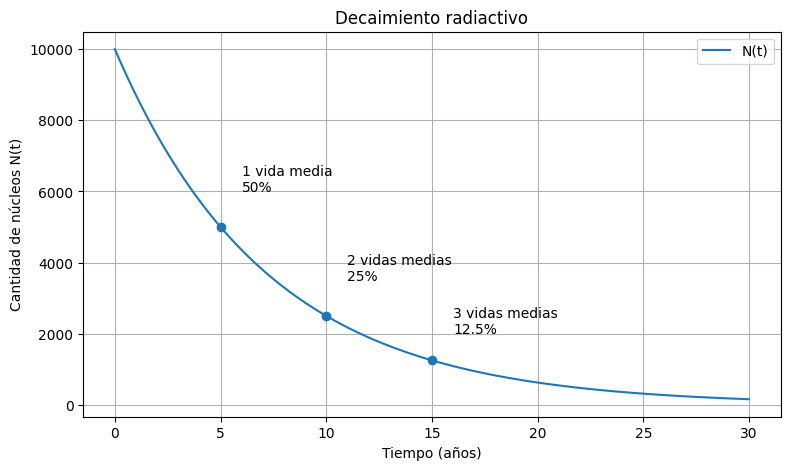

In [38]:
# --- B.4: Gráfica del decaimiento radiactivo ---

plt.figure(figsize=(9, 5))

plt.plot(t, N, label="N(t)")

# Marcar 1, 2 y 3 vidas medias
tiempos_half = np.array([5, 10, 15])
valores_half = N_decaimiento(tiempos_half)

plt.scatter(tiempos_half, valores_half, zorder=3)

# Etiquetas de los puntos
plt.annotate("1 vida media\n50%", (5, 5000),
             xytext=(6, 6000))

plt.annotate("2 vidas medias\n25%", (10, 2500),
             xytext=(11, 3500))

plt.annotate("3 vidas medias\n12.5%", (15, 1250),
             xytext=(16, 2000))

plt.title("Decaimiento radiactivo")
plt.xlabel("Tiempo (años)")
plt.ylabel("Cantidad de núcleos N(t)")
plt.grid(True)
plt.legend()

plt.show()

**Punto 5**

In [39]:
# --- B.5: Tiempos para alcanzar ciertas fracciones ---

fracciones = [0.50, 0.25, 0.10]

for f in fracciones:
    tiempo = -np.log(f) / lam
    print(f"{f*100:.0f}% de la cantidad inicial: {tiempo:.4f} años")

50% de la cantidad inicial: 5.0000 años
25% de la cantidad inicial: 10.0000 años
10% de la cantidad inicial: 16.6096 años



El modelo de decaimiento radiactivo permitió representar mediante Python la disminución de una cantidad de núcleos en función del tiempo. Se obtuvo una constante de decaimiento de $\lambda = 0.1386\ \text{año}^{-1}$ y se verificó que la cantidad se reduce a la mitad cada 5 años. Además, mediante NumPy y Matplotlib fue posible calcular y visualizar el comportamiento del sistema, obteniendo que el 10 % de la cantidad inicial se alcanza aproximadamente a los 16.61 años.


**C. CELDA DE VERIFICACIÓN**


Todas las pruebas realizadas para las Partes A y B dieron como resultado `PASS`. Esto confirma que las funciones implementadas producen resultados dentro de las tolerancias establecidas y que los cálculos realizados son consistentes con los valores esperados.


In [44]:
# --- Comparación con valores de referencia para el reporte ---

casos_reporte = [
    (5.0, 5000.0),
    (10.0, 2500.0),
    (15.0, 1250.0)
]

print(f"{'Tiempo (años)':>15} {'Obtenido':>15} {'Referencia':>15} {'Error relativo (%)':>20}")
print("-" * 70)

for tiempo, referencia in casos_reporte:
    obtenido = N_decaimiento(tiempo)
    error_relativo = abs((obtenido - referencia) / referencia) * 100

    print(f"{tiempo:15.1f} {obtenido:15.6f} {referencia:15.6f} {error_relativo:20.12e}")

  Tiempo (años)        Obtenido      Referencia   Error relativo (%)
----------------------------------------------------------------------
            5.0     5000.000000     5000.000000   0.000000000000e+00
           10.0     2500.000000     2500.000000   0.000000000000e+00
           15.0     1250.000000     1250.000000   1.818989403546e-14


****

## 11. Referencias

- Presentación de la Semana 2: `Semana_02_EstructurasControl.pdf`.
- Heath, M. T. *Scientific Computing: An Introductory Survey*, 2.ª ed. revisada — Cap. 1 (*Scientific Computing*): fuente de los ejemplos de condicionamiento (número de condición), cancelación en el átomo de helio y la fórmula cuadrática de la sección 6.